In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
file_path = r"D:\github\AAE625_2026\RetailData.csv"
df = pd.read_csv(file_path, sep='|', index_col=0)

df.columns = df.columns.str.strip()
print("clean：", df.columns.tolist())

clean： ['STORE_ID', 'PRICE', 'QUANTITY', 'REVENUE', 'AVERAGE_LENGTH_OF_RESIDENCE', 'PERCENTAGE_OF_RENTERS', 'PERCENT_HAVING_CHILDREN', 'AVERAGE_INCOME', 'AVERAGE_AGE_IN_YEARS', 'PERCENT_SPEAKING_SPANISH']


In [11]:
# ── 1. Fit the log-log regression model ──
df['ln_QTY']      = np.log(df['QUANTITY'])
df['ln_PRICE']    = np.log(df['PRICE'])
df['ln_INCOME']   = np.log(df['AVERAGE_INCOME'])
df['ln_RENTERS']  = np.log(df['PERCENTAGE_OF_RENTERS'])
df['ln_CHILDREN'] = np.log(df['PERCENT_HAVING_CHILDREN'])
df['ln_SPANISH']  = np.log(df['PERCENT_SPEAKING_SPANISH'])

X = sm.add_constant(df[['ln_PRICE', 'ln_INCOME', 'ln_RENTERS', 'ln_CHILDREN', 'ln_SPANISH']])
y = df['ln_QTY']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 ln_QTY   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     113.1
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.47e-65
Time:                        22:32:05   Log-Likelihood:                -30.391
No. Observations:                 291   AIC:                             72.78
Df Residuals:                     285   BIC:                             94.82
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           8.7401      0.706     12.373      

In [ ]:

#  Construct PRICE_DELTA and R_QUANTITY 
df['PRICE_DELTA'] = df['PRICE'] - df['PRICE'].mean()
df['R_QUANTITY']  = df['QUANTITY'] - np.exp(model.fittedvalues)

# 3. Standardize & K-Means (K=5) 
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[['PRICE_DELTA', 'R_QUANTITY']])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(features_scaled)

#  4. Report 
print(f"\nIterations to convergence: {kmeans.n_iter_}")

centers_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['PRICE_DELTA (scaled)', 'R_QUANTITY (scaled)'],
    index=[f'Cluster {i}' for i in range(5)]
)
print("\nCluster Centers:")
print(centers_df.round(4))

print("\nCluster Sizes:")
print(pd.Series(kmeans.labels_).value_counts().sort_index())


Iterations to convergence: 10

Cluster Centers:
           PRICE_DELTA (scaled)  R_QUANTITY (scaled)
Cluster 0               -1.5100              -0.4280
Cluster 1                0.1641               0.2082
Cluster 2                0.0644              -1.3476
Cluster 3                1.7417              -0.5373
Cluster 4               -0.1069               1.5946

Cluster Sizes:
0     51
1    121
2     41
3     34
4     44
Name: count, dtype: int64


d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


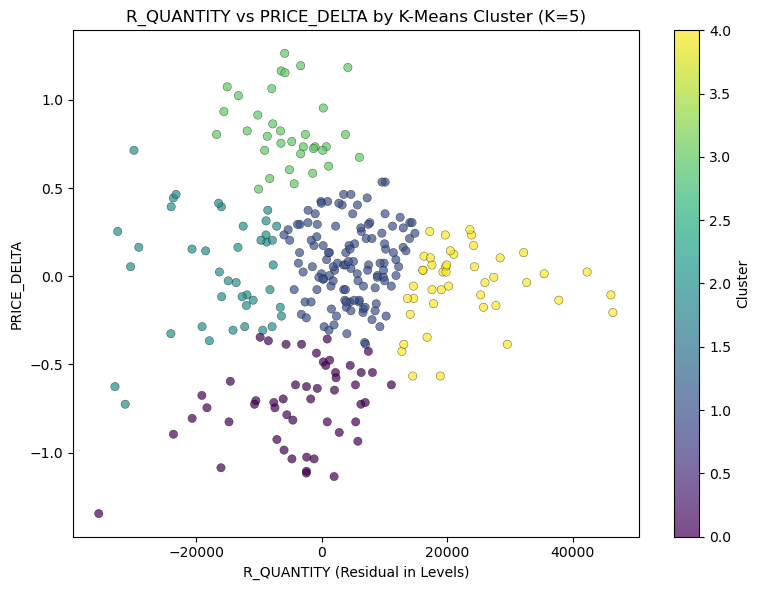

In [13]:
df['Cluster'] = kmeans.labels_

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['R_QUANTITY'], df['PRICE_DELTA'],
    c=df['Cluster'], cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.3
)
plt.xlabel('R_QUANTITY (Residual in Levels)')
plt.ylabel('PRICE_DELTA')
plt.title('R_QUANTITY vs PRICE_DELTA by K-Means Cluster (K=5)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150)
plt.show()

In [14]:
cluster_summary = df.groupby('Cluster')[['PRICE_DELTA', 'R_QUANTITY']].mean()
print("Mean PRICE_DELTA and R_QUANTITY by Cluster:")
print(cluster_summary.round(4))

Mean PRICE_DELTA and R_QUANTITY by Cluster:
         PRICE_DELTA  R_QUANTITY
Cluster                         
0            -0.7211  -3881.8345
1             0.0784   4535.7401
2             0.0307 -16049.4787
3             0.8318  -5328.2884
4            -0.0511  22880.8741



**Cluster 1: Low-Priced, Moderate Under-Performers **
These stores price below average but still sell less than the model predicts. Possible explanations include unfavorable locations or weak local demand that low pricing alone cannot overcome.

**Cluster 2: Average-Priced, Moderate Over-Performers **
 These stores charge near the sample mean price yet sell substantially more than predicted. They likely benefit from strong local demand drivers not captured by the model, for example, high foot traffic, good store management, or brand loyalty

**Cluster 3: Average-Priced, Severe Under-Performers **
 Priced near the mean but with the largest negative residual, actual sales fall far below predictions. These are the weakest-performing stores and may face structural demand problems, poor location, or strong local competition.
**Cluster 4: High-Priced, Under-Performers**
These stores charge well above average and sell less than predicted. This is consistent with overpricing.The high price deters purchases beyond what the model already accounts for through the price elasticity coefficient.

**Cluster 5: Low-Priced, Strong Over-Performers **
These stores have the highest positive residual by far, meaning actual sales vastly exceed predictions. They represent the top-performing stores. They are likely located in high-demand areas with favorable demographics, effectively capturing market share at competitive prices.
